In [1]:
import warnings
warnings.filterwarnings("ignore")  # suppress tqdm progress bars and internal warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import shapiq
from shapiq import TabularExplainer
from shapiq.datasets import load_bike_sharing_daily, load_bike_sharing_daily_train_index

print(f"shapiq version: {shapiq.__version__}")

shapiq version: None


## 1. Load Bike Sharing Daily Data

The paper uses the UCI Bike Sharing Dataset (daily aggregates) with specific preprocessing:
- **trend**: Days since January 1, 2011
- **cosyear**: cos(2π × trend / 365) - cyclical season
- **sinyear**: sin(2π × trend / 365) - cyclical season
- **temp**: Unnormalized temperature (°C)
- **atemp**: Unnormalized feeling temperature (°C)
- **windspeed**: Unnormalized wind speed
- **hum**: Unnormalized humidity (%)
- **location**: Constant feature (value = 1.0) representing a single location for all samples. 

> **Source**: [`src/shapiq/datasets/_all.py`](../../src/shapiq/datasets/_all.py) → `load_bike_sharing_daily()` (Line 73-134)
>
> **Note**: The `location` feature is not in the original dataset but is added in this notebook to demonstrate an alternative causal ordering where location serves as a root cause alongside temporal trend (see Section 3 for the complete causal graph).

In [2]:
x_data, y_data = load_bike_sharing_daily(preprocessed=True)
train_idx = load_bike_sharing_daily_train_index()

# Add location as a constant feature (same location for all samples)
x_data = x_data.copy()
x_data['location'] = 1.0

feature_names = ["trend", "cosyear", "sinyear", "temp", "atemp", "windspeed", "hum", "location"]

all_idx = np.arange(len(x_data))
test_idx = np.array([i for i in all_idx if i not in train_idx])

print(f"Total samples: {len(x_data)} (CSV rows 2-732 in day.csv)")
print(f"Training samples: {len(train_idx)} (indices from train_index.npy)")
print(f"Test samples: {len(test_idx)} (DataFrame indices: {test_idx.tolist()[:10]}...{test_idx.tolist()[-5:]})")
print(f"Test CSV rows: {(test_idx + 2).tolist()[:10]}...{(test_idx + 2).tolist()[-5:]}")
print(f"Features: {feature_names}")


Total samples: 731 (CSV rows 2-732 in day.csv)
Training samples: 587 (indices from train_index.npy)
Test samples: 144 (DataFrame indices: [13, 14, 29, 32, 37, 41, 44, 46, 48, 50]...[702, 706, 713, 719, 726])
Test CSV rows: [15, 16, 31, 34, 39, 43, 46, 48, 50, 52]...[704, 708, 715, 721, 728]
Features: ['trend', 'cosyear', 'sinyear', 'temp', 'atemp', 'windspeed', 'hum', 'location']


In [3]:
# Prepare data with centering (as in original paper)
X_train = x_data.iloc[train_idx].values
y_train_nc = y_data.iloc[train_idx].values  # not centered
y_train_mean = y_train_nc.mean()
y_train = y_train_nc - y_train_mean  # centered

X_test = x_data.iloc[test_idx].values
y_test = y_data.iloc[test_idx].values - y_train_mean  # centered using train mean

print(f"y_train mean (φ₀): {y_train_mean:.2f}")

y_train mean (φ₀): 4505.03


## 1.1. Data Visualization: Bike Rentals Over Time

Before training the model, let's visualize the raw data to understand the relationship between time, temperature, and bike rentals. This reproduces the exploratory data analysis from the paper.

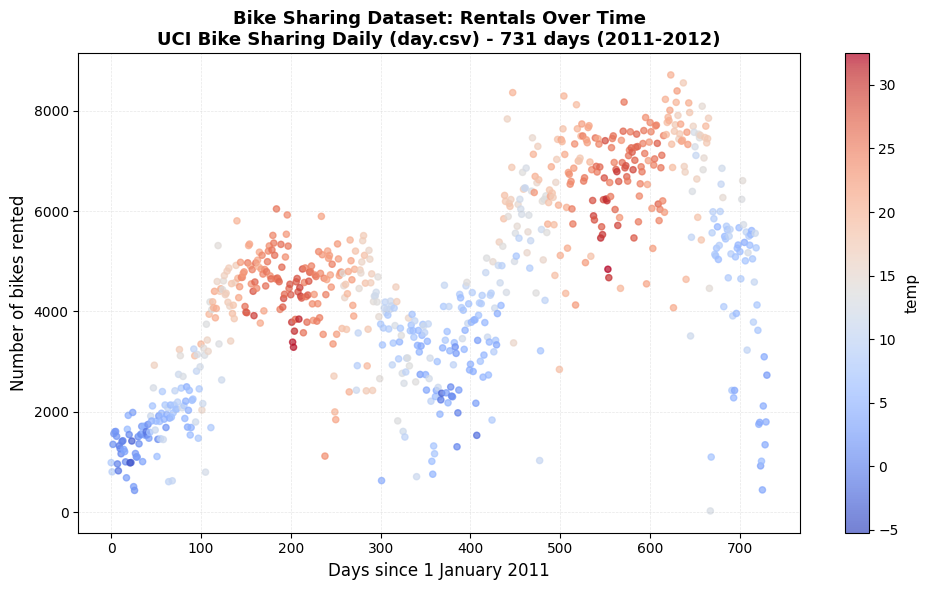

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

trend_values = x_data['trend'].values
temp_values = x_data['temp'].values
y_values = y_data.values

scatter = ax.scatter(trend_values, y_values, c=temp_values, 
                     cmap='coolwarm', s=20, alpha=0.7)

ax.set_xlabel('Days since 1 January 2011', fontsize=12)
ax.set_ylabel('Number of bikes rented', fontsize=12)
ax.set_title('Bike Sharing Dataset: Rentals Over Time\n'
             'UCI Bike Sharing Daily (day.csv) - 731 days (2011-2012)', 
             fontsize=13, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('temp', fontsize=11)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


## 2. Train XGBoost Model

In [5]:
model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=1,
    verbosity=0
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Test RMSE (centered): {rmse:.2f}")

Test RMSE (centered): 775.24


## 3. Define Alternative Causal Structure

This notebook uses an **alternative causal ordering** different from the original paper:

```
[trend, location]  (Layer 1: Root causes)
       |
       v
[cosyear, sinyear, temp, hum, windspeed]  (Layer 2: Season & Weather)
       |                                    ← atmospheric_state (unobserved confounder)
       v
    [atemp]  (Layer 3: Feeling temperature)
       |
       v
    [count]  (Target: bike rentals)
```

Key differences from the original paper:
- **Location** is added as a constant feature (same location for all samples)
- **Layer 2 confounding**: `atmospheric_state` acts as an unobserved common cause of the weather variables in Layer 2. Although it cannot be directly measured, setting `confounding = True` for this layer instructs the imputer to perform **joint sampling** (rather than independent sampling) of cosyear, sinyear, temp, hum, and windspeed, thereby preserving their natural correlation structure. Layer 1 (exogenous time variables) and Layer 3 (single variable) do not require this treatment.
- **atemp (feeling temperature)** is in a separate layer as it depends on temp, humidity, and windspeed
- This structure treats season (cosyear, sinyear) and weather (temp, hum, windspeed) as being at the same causal level

In [6]:
# Alternative causal ordering:
# Layer 1: [trend, location] - root causes (date and location)
# Layer 2: [cosyear, sinyear, temp, hum, windspeed] - season and weather variables
# Layer 3: [atemp] - feeling temperature depends on temp, humidity, windspeed

# Feature indices:
# 0: trend, 1: cosyear, 2: sinyear, 3: temp, 4: atemp, 5: windspeed, 6: hum, 7: location

ordering = [
    [0, 7],              # Layer 1: trend, location (root causes)
    [1, 2, 3, 6, 5],     # Layer 2: cosyear, sinyear, temp, hum, windspeed
    [4],                 # Layer 3: atemp (feeling temperature)
]

# Confounding flags per layer:
# Layer 1 (False): exogenous root causes — no unobserved common cause
# Layer 2 (True):  atmospheric_state is an unobserved confounder → joint sampling
# Layer 3 (False): single variable — confounding is irrelevant
confounding = [False, True, False]

print("Alternative Causal Structure:")
for i, layer in enumerate(ordering):
    layer_names = [feature_names[j] for j in layer]
    print(f"  Layer {i+1}: {layer_names} (confounding={confounding[i]})")


Alternative Causal Structure:
  Layer 1: ['trend', 'location'] (confounding=False)
  Layer 2: ['cosyear', 'sinyear', 'temp', 'hum', 'windspeed'] (confounding=True)
  Layer 3: ['atemp'] (confounding=False)


## 4. Create Explainers

- **Marginal**: Standard SHAP (assumes feature independence)
- **Causal**: Uses CausalImputer with copula sampling and the **alternative ordering**:
  - Layer 1: `[trend, location]` → Layer 2: `[cosyear, sinyear, temp, hum, windspeed]` → Layer 3: `[atemp]`
  - Layer 2 has `confounding = True` (unobserved `atmospheric_state` as common cause → joint sampling to preserve weather variable correlations)

> **Note on Sampling Methods**: This notebook uses **Copula sampling only** (not Gaussian) for the following reasons:
> 1. **Constant feature handling**: Gaussian sampling does not handle constant features (like `location`) well
> 2. **Marginal distribution preservation**: Copula preserves the original marginal distributions, which is more robust for non-Gaussian data like bike rentals
> 3. **Empirical evidence**: As shown in [`paper_figure3_reproduction.ipynb`](./paper_figure3_reproduction.ipynb), Gaussian vs Copula methods show minimal differences in results, making Copula the preferred choice due to its better theoretical properties and broader applicability

In [7]:
RANDOM_STATE = 42
SAMPLE_SIZE = 1000

explainers = {}

# Marginal (Joint)
explainers['Marginal (Joint)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# Marginal (Copula)
explainers['Marginal (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# Causal + Model (Copula)
explainers['Causal+ML (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="causal",
    ordering=ordering,
    confounding=confounding,
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# Causal No-ML (Y as final node in causal graph)
explainers['Causal No-ML (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="no_ml_causal",
    y=y_train,
    ordering=ordering,
    confounding=confounding,
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

print(f"Explainers ready: {list(explainers.keys())}")


Explainers ready: ['Marginal (Joint)', 'Marginal (Copula)', 'Causal+ML (Copula)', 'Causal No-ML (Copula)']


## 5. Compute Shapley Values for All Test Samples

>  **Note**: This step computes Shapley values for all 4 methods across all test samples. Expected runtime: **80-100 minutes** depending on your hardware.

In [8]:
budget = 2048
n_features = len(feature_names)

all_ksii = {}
all_sv = {}

for exp_name, explainer in explainers.items():
    print(f"\nComputing k-SII (max_order=2) for {exp_name} across {len(X_test)} samples...")
    ksii_list = []
    sv = np.zeros((len(X_test), n_features))
    
    for i in range(len(X_test)):
        result = explainer.explain(X_test[i:i+1], budget=budget)
        ksii_list.append(result)
        sv[i] = result.get_n_order_values(order=1)
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(X_test)}")
    
    all_ksii[exp_name] = ksii_list
    all_sv[exp_name] = sv
    print(f"  Done!")

print("\nAll k-SII values computed.")



Computing k-SII (max_order=2) for Marginal (Joint) across 144 samples...


  Processed 50/144
  Processed 100/144
  Done!

Computing k-SII (max_order=2) for Marginal (Copula) across 144 samples...
  Processed 50/144
  Processed 100/144
  Done!

Computing k-SII (max_order=2) for Causal+ML (Copula) across 144 samples...
  Processed 50/144
  Processed 100/144
  Done!

Computing k-SII (max_order=2) for Causal No-ML (Copula) across 144 samples...
  Processed 50/144
  Processed 100/144
  Done!

All k-SII values computed.


## 6. Scatter Plots: 2×2 Grid Comparison

In [9]:
# For paper reproduction: use only the two methods
# - MSV: Marginal (Joint) = standard marginal SHAP
# - CSV: Causal+ML (Copula) = causal method with copula sampling
sv_marginal = all_sv['Marginal (Joint)']
sv_causal = all_sv['Causal+ML (Copula)']

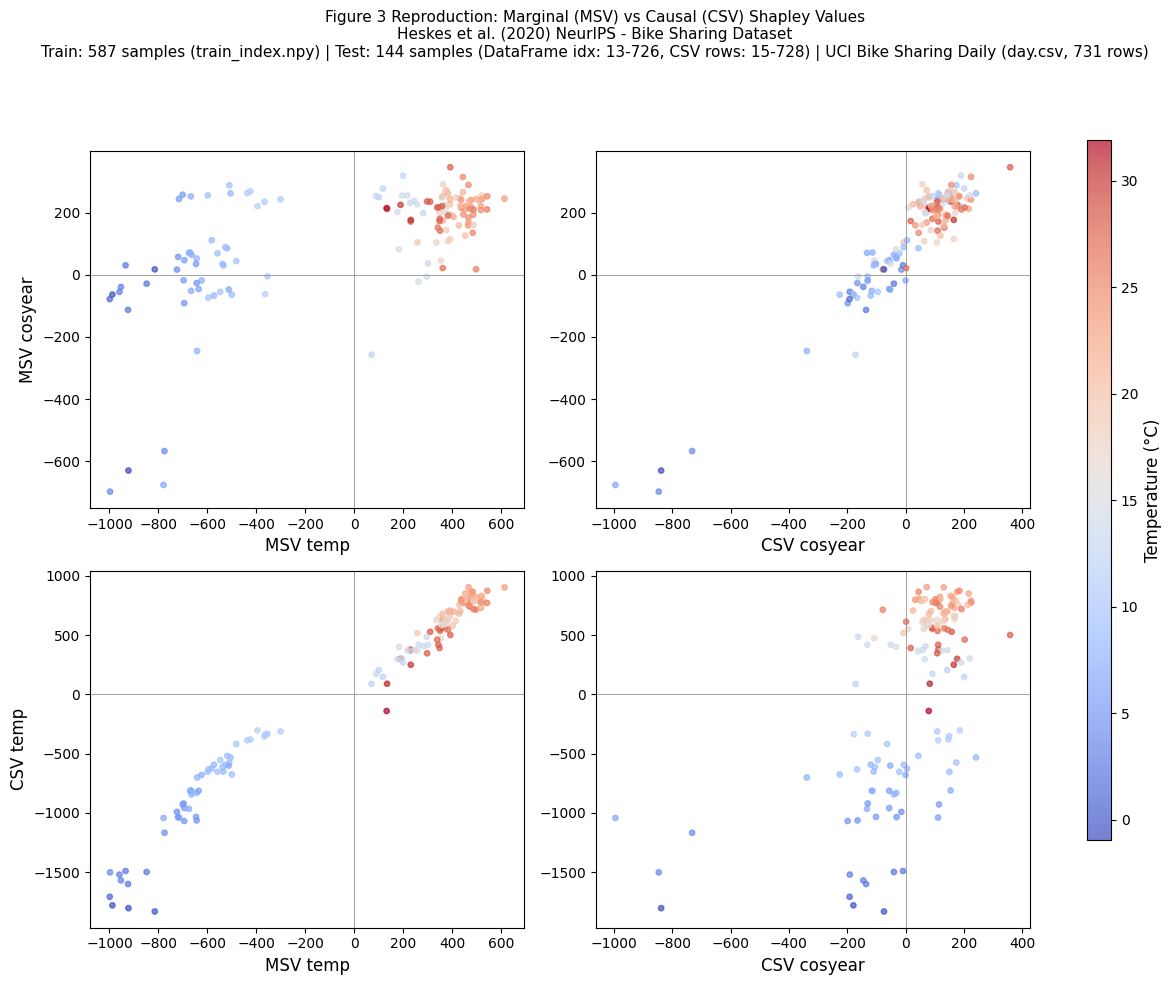

In [10]:
# Get feature indices
temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')

# Get Shapley values for temp and cosyear
sv_marg_temp = sv_marginal[:, temp_idx]
sv_marg_cosyear = sv_marginal[:, cosyear_idx]
sv_caus_temp = sv_causal[:, temp_idx]
sv_caus_cosyear = sv_causal[:, cosyear_idx]

# Temperature values for coloring
temp_values = X_test[:, temp_idx]

# Create 2x2 figure matching paper layout (wider to accommodate colorbar)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cmap = 'coolwarm'
point_size = 15

# Top left: MSV temp (x) vs MSV cosyear (y)
ax = axes[0, 0]
scatter = ax.scatter(sv_marg_temp, sv_marg_cosyear, c=temp_values, 
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('MSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Top right: CSV cosyear (x) vs MSV cosyear (y)
ax = axes[0, 1]
ax.scatter(sv_caus_cosyear, sv_marg_cosyear, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom left: MSV temp (x) vs CSV temp (y)
ax = axes[1, 0]
ax.scatter(sv_marg_temp, sv_caus_temp, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('CSV temp', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom right: CSV cosyear (x) vs CSV temp (y)
ax = axes[1, 1]
scatter = ax.scatter(sv_caus_cosyear, sv_caus_temp, c=temp_values,
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Add colorbar with better positioning
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=12)

# Get test CSV rows for display
test_csv_rows = test_idx + 2
plt.suptitle('Figure 3 Reproduction: Marginal (MSV) vs Causal (CSV) Shapley Values\n'
             'Heskes et al. (2020) NeurIPS - Bike Sharing Dataset\n'
             f'Train: {len(train_idx)} samples (train_index.npy) | '
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]}) | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=11)
plt.tight_layout(rect=[0, 0, 0.88, 0.92])
plt.show()

## 7. Beeswarm Comparison (All Methods)

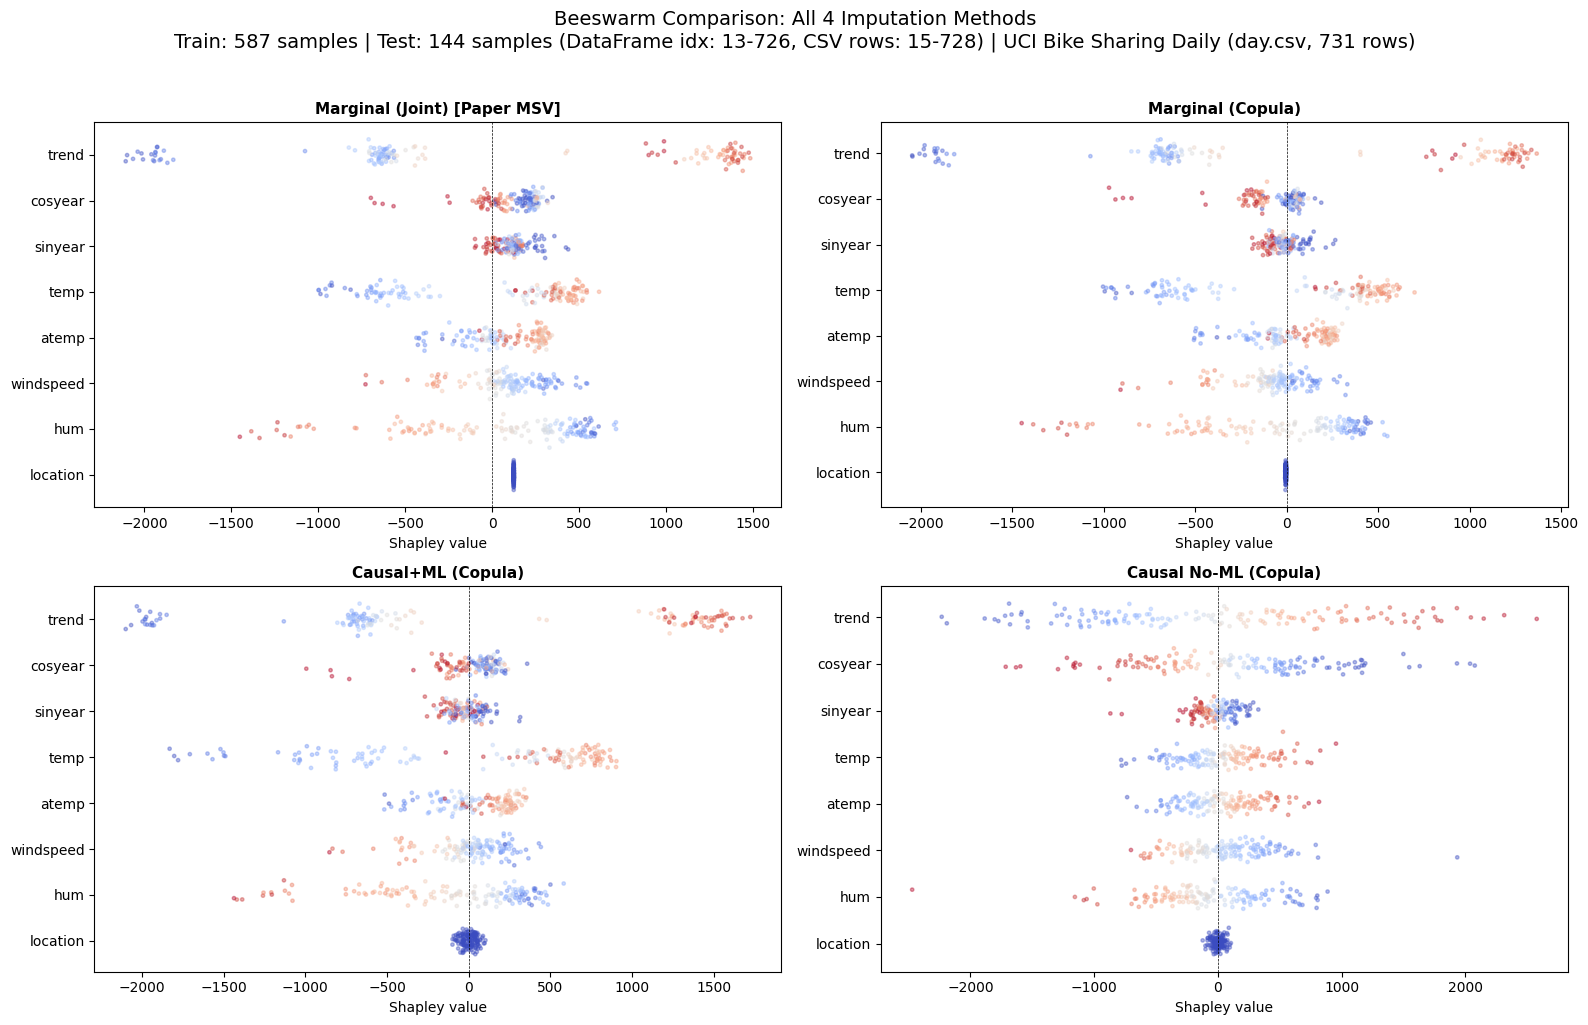

In [11]:
# Create 2x2 beeswarm comparison for ALL methods
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Fixed feature order (matching feature_names, consistent across notebooks)
order = list(range(len(feature_names)))

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    for i, f_idx in enumerate(order):
        fv = X_test[:, f_idx]
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-10)
        
        y_jitter = np.random.normal(0, 0.12, len(sv)) + (len(feature_names) - 1 - i)
        ax.scatter(sv[:, f_idx], y_jitter, c=fv_norm, cmap='coolwarm', 
                  alpha=0.4, s=6)
    
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[order[len(feature_names) - 1 - i]] 
                        for i in range(len(feature_names))])
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Shapley value')
    
    # Mark paper methods
    title = exp_name
    if exp_name == 'Marginal (Joint)':
        title += ' [Paper MSV]'
    ax.set_title(title, fontsize=11, fontweight='bold')

# Get test CSV rows for display
test_csv_rows = test_idx + 2
plt.suptitle('Beeswarm Comparison: All 4 Imputation Methods\n'
             f'Train: {len(train_idx)} samples | '
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]}) | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [12]:
test_csv_rows = test_idx + 2

summary_df = pd.DataFrame(index=feature_names)
for exp_name, sv in all_sv.items():
    summary_df[exp_name] = np.abs(sv).mean(axis=0)

# Shorter column names for display
short_names = {
    'Marginal (Joint)': 'Marg(Joint)',
    'Marginal (Copula)': 'Marg(Copula)',
    'Causal+ML (Copula)': 'Caus+ML(Copula)',
    'Causal No-ML (Copula)': 'NoML'
}
summary_df.columns = [short_names.get(c, c) for c in summary_df.columns]

print(summary_df.round(2).to_string())


           Marg(Joint)  Marg(Copula)  Caus+ML(Copula)    NoML
trend          1055.89       1006.11          1096.91  896.64
cosyear         182.16        112.64           136.65  615.54
sinyear         120.88         60.33            77.30  120.08
temp            470.24        504.64           699.35  266.76
atemp           186.08        179.88           184.54  243.05
windspeed       189.81        145.79           161.63  268.98
hum             448.26        386.11           375.14  367.61
location        123.30          5.72            36.32   34.85


## 9. Two Similar Days Analysis



October day 2012-10-09 (DataFrame idx 647, CSV row 649): temp=13.0°C, cosyear=0.14
December day 2012-12-03 (DataFrame idx 702, CSV row 704): temp=13.3°C, cosyear=0.89


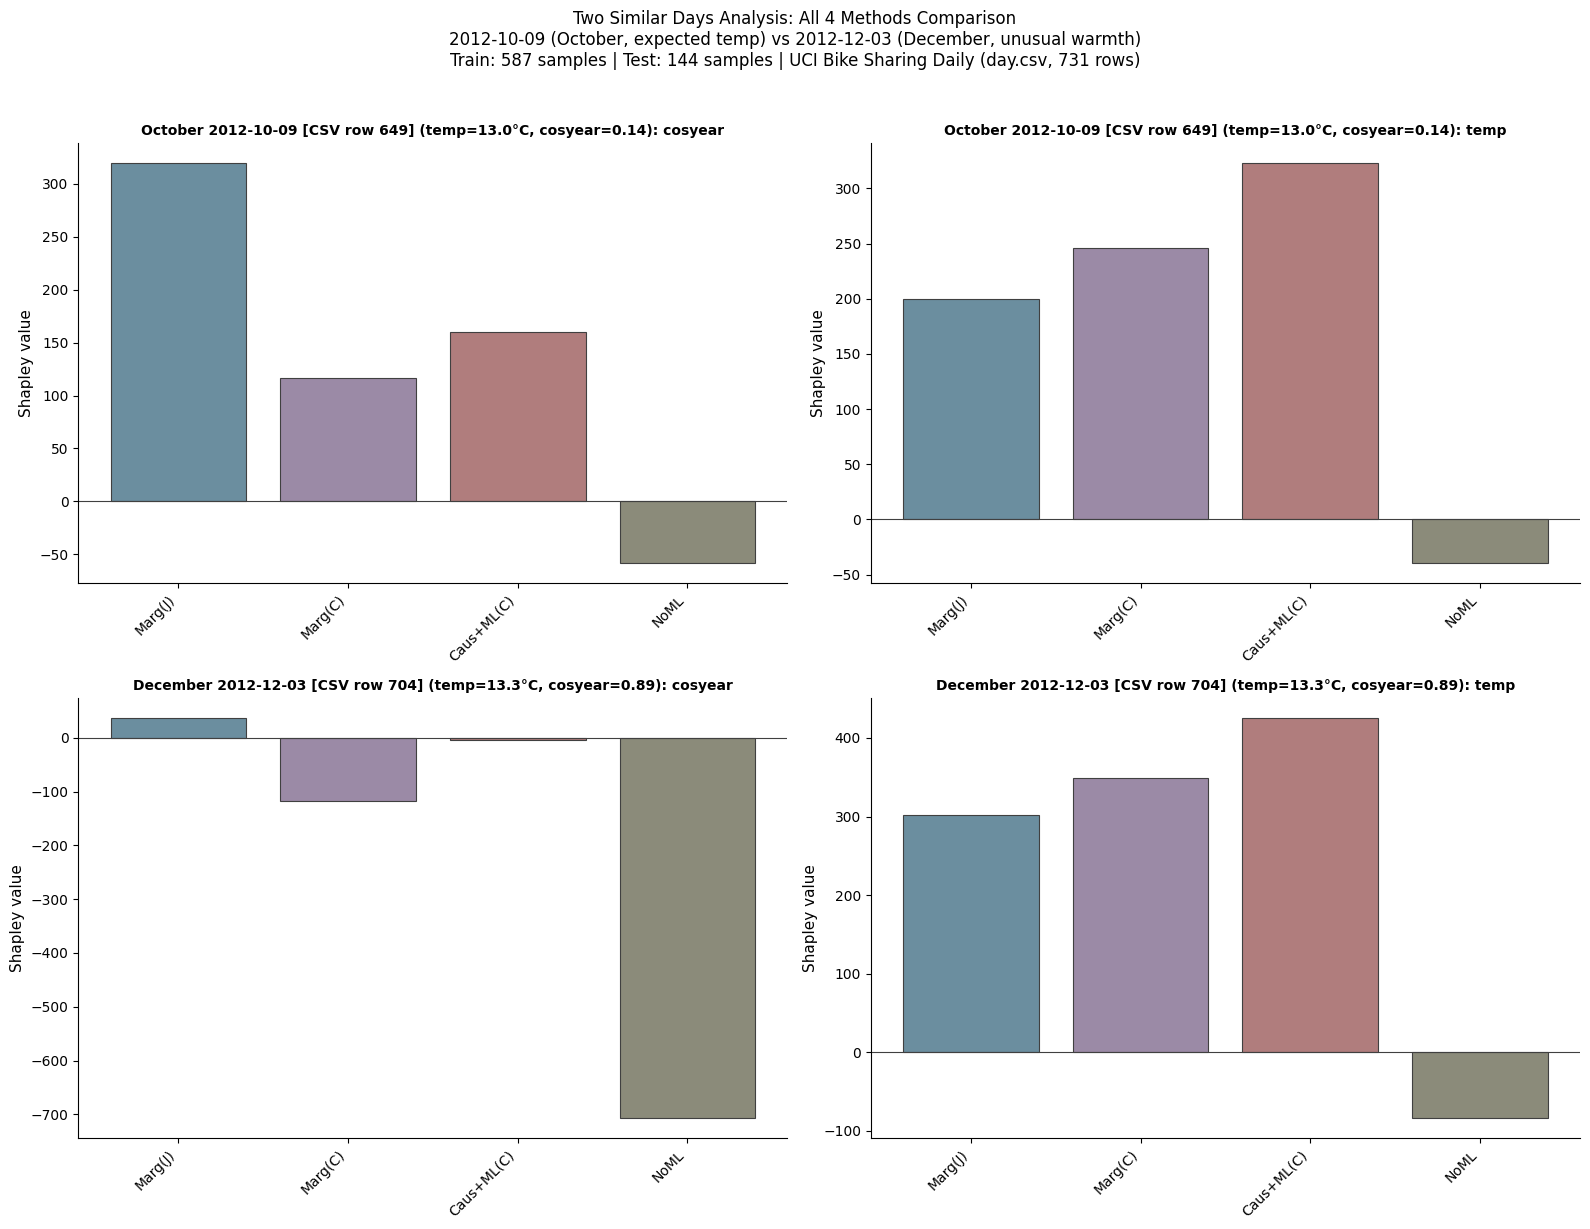

In [13]:
# match R code (bike_rental_illustration.R):
#   october <- which(bike$dteday == "2012-10-09")  → instant 648
#   december <- which(bike$dteday == "2012-12-03") → instant 703
# DataFrame index (0-based) = instant - 1

x_full, y_full = load_bike_sharing_daily(preprocessed=True)
x_full = x_full.copy()
x_full['location'] = 1.0

october_idx = 647   # 2012-10-09 (instant=648): temp≈13.0°C, cosyear≈0.14
december_idx = 702  # 2012-12-03 (instant=703): temp≈13.3°C, cosyear≈0.89

october_csv_row = october_idx + 2
december_csv_row = december_idx + 2

print(f"October day 2012-10-09 (DataFrame idx {october_idx}, CSV row {october_csv_row}): "
      f"temp={x_full.loc[october_idx, 'temp']:.1f}°C, "
      f"cosyear={x_full.loc[october_idx, 'cosyear']:.2f}")
print(f"December day 2012-12-03 (DataFrame idx {december_idx}, CSV row {december_csv_row}): "
      f"temp={x_full.loc[december_idx, 'temp']:.1f}°C, "
      f"cosyear={x_full.loc[december_idx, 'cosyear']:.2f}")

days_x = x_full.loc[[october_idx, december_idx], feature_names].values

sv_days_all = {}
for exp_name, explainer in explainers.items():
    sv_days = []
    for x in days_x:
        result = explainer.explain(x.reshape(1, -1), budget=budget)
        sv_days.append(result.get_n_order_values(order=1))
    sv_days_all[exp_name] = np.array(sv_days)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# colors
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-ML)
]
short_names = ['Marg(J)', 'Marg(C)', 'Caus+ML(C)', 'NoML']

oct_temp = x_full.loc[october_idx, 'temp']
oct_cosyear = x_full.loc[october_idx, 'cosyear']
dec_temp = x_full.loc[december_idx, 'temp']
dec_cosyear = x_full.loc[december_idx, 'cosyear']

for ax_idx, (fname, f_idx) in enumerate([('cosyear', cosyear_idx), ('temp', temp_idx)]):
    ax = axes[0, ax_idx]
    x_pos = np.arange(len(explainers))
    values = [sv_days_all[name][0, f_idx] for name in explainers.keys()]
    bars = ax.bar(x_pos, values, color=colors, edgecolor='#404040', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.axhline(y=0, color='#404040', linewidth=0.8)
    ax.set_ylabel('Shapley value', fontsize=11)
    ax.set_title(f'October 2012-10-09 [CSV row {october_csv_row}] (temp={oct_temp:.1f}°C, cosyear={oct_cosyear:.2f}): {fname}', 
                 fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax = axes[1, ax_idx]
    values = [sv_days_all[name][1, f_idx] for name in explainers.keys()]
    bars = ax.bar(x_pos, values, color=colors, edgecolor='#404040', linewidth=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.axhline(y=0, color='#404040', linewidth=0.8)
    ax.set_ylabel('Shapley value', fontsize=11)
    ax.set_title(f'December 2012-12-03 [CSV row {december_csv_row}] (temp={dec_temp:.1f}°C, cosyear={dec_cosyear:.2f}): {fname}', 
                 fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Two Similar Days Analysis: All 4 Methods Comparison\n'
             '2012-10-09 (October, expected temp) vs 2012-12-03 (December, unusual warmth)\n'
             f'Train: {len(train_idx)} samples | Test: {len(test_idx)} samples | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---

# Part II: Comprehensive Imputer Comparison (Additional Analysis)

> **Note**: This section contains **additional exploratory analysis** beyond the paper reproduction. These visualizations provide deeper insights into the differences between all 4 imputation methods (excluding Gaussian variants) and are useful for understanding the behavior of various Shapley value computation approaches with copula-based sampling.

Now we compare all 4 imputation methods systematically to understand how different assumptions affect Shapley value attributions.

## 10. Feature Importance Comparison Across All Imputers

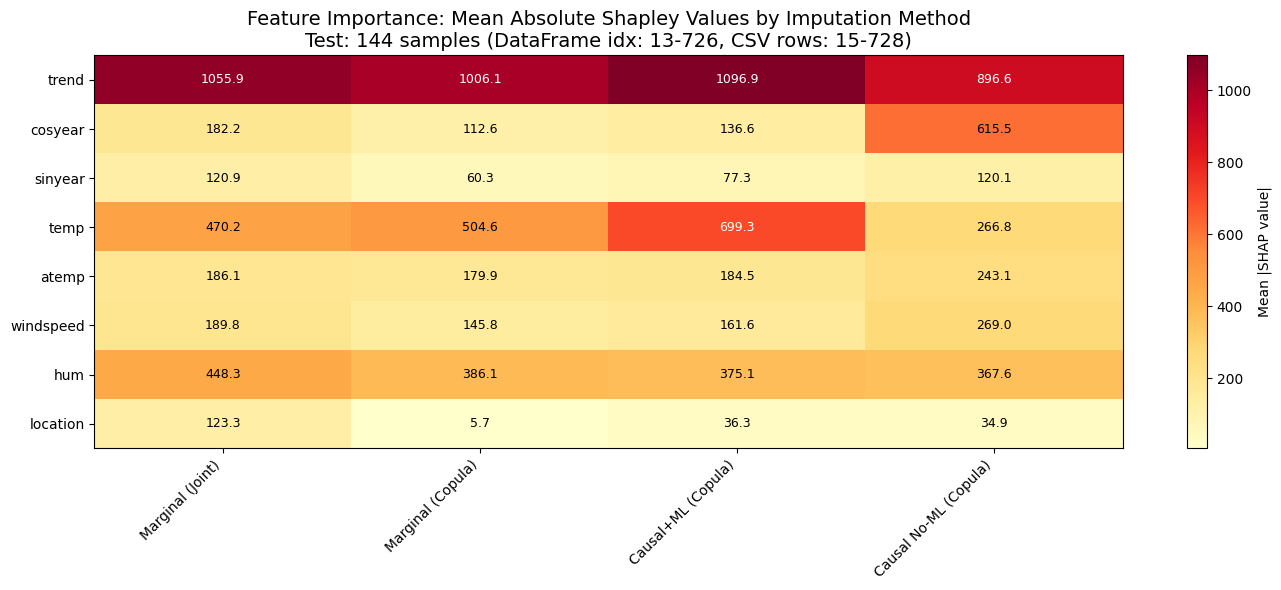

           Marginal (Joint)  Marginal (Copula)  Causal+ML (Copula)  Causal No-ML (Copula)
trend               1055.89            1006.11             1096.91                 896.64
cosyear              182.16             112.64              136.65                 615.54
sinyear              120.88              60.33               77.30                 120.08
temp                 470.24             504.64              699.35                 266.76
atemp                186.08             179.88              184.54                 243.05
windspeed            189.81             145.79              161.63                 268.98
hum                  448.26             386.11              375.14                 367.61
location             123.30               5.72               36.32                  34.85


In [14]:
importance_df = pd.DataFrame(index=feature_names)

for exp_name, sv in all_sv.items():
    importance_df[exp_name] = np.abs(sv).mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(importance_df.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(importance_df.columns)))
ax.set_xticklabels(importance_df.columns, rotation=45, ha='right')
ax.set_yticks(range(len(importance_df.index)))
ax.set_yticklabels(importance_df.index)

for i in range(len(importance_df.index)):
    for j in range(len(importance_df.columns)):
        val = importance_df.iloc[i, j]
        color = 'white' if val > importance_df.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, label='Mean |SHAP value|')
test_csv_rows = test_idx + 2
plt.title(f'Feature Importance: Mean Absolute Shapley Values by Imputation Method\n'
         f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
         fontsize=14)
plt.tight_layout()
plt.show()

print(importance_df.round(2).to_string())


## 11. Focus on temp vs cosyear Attribution

The key comparison: how does each method attribute importance between temperature (direct effect) and season (root cause)?

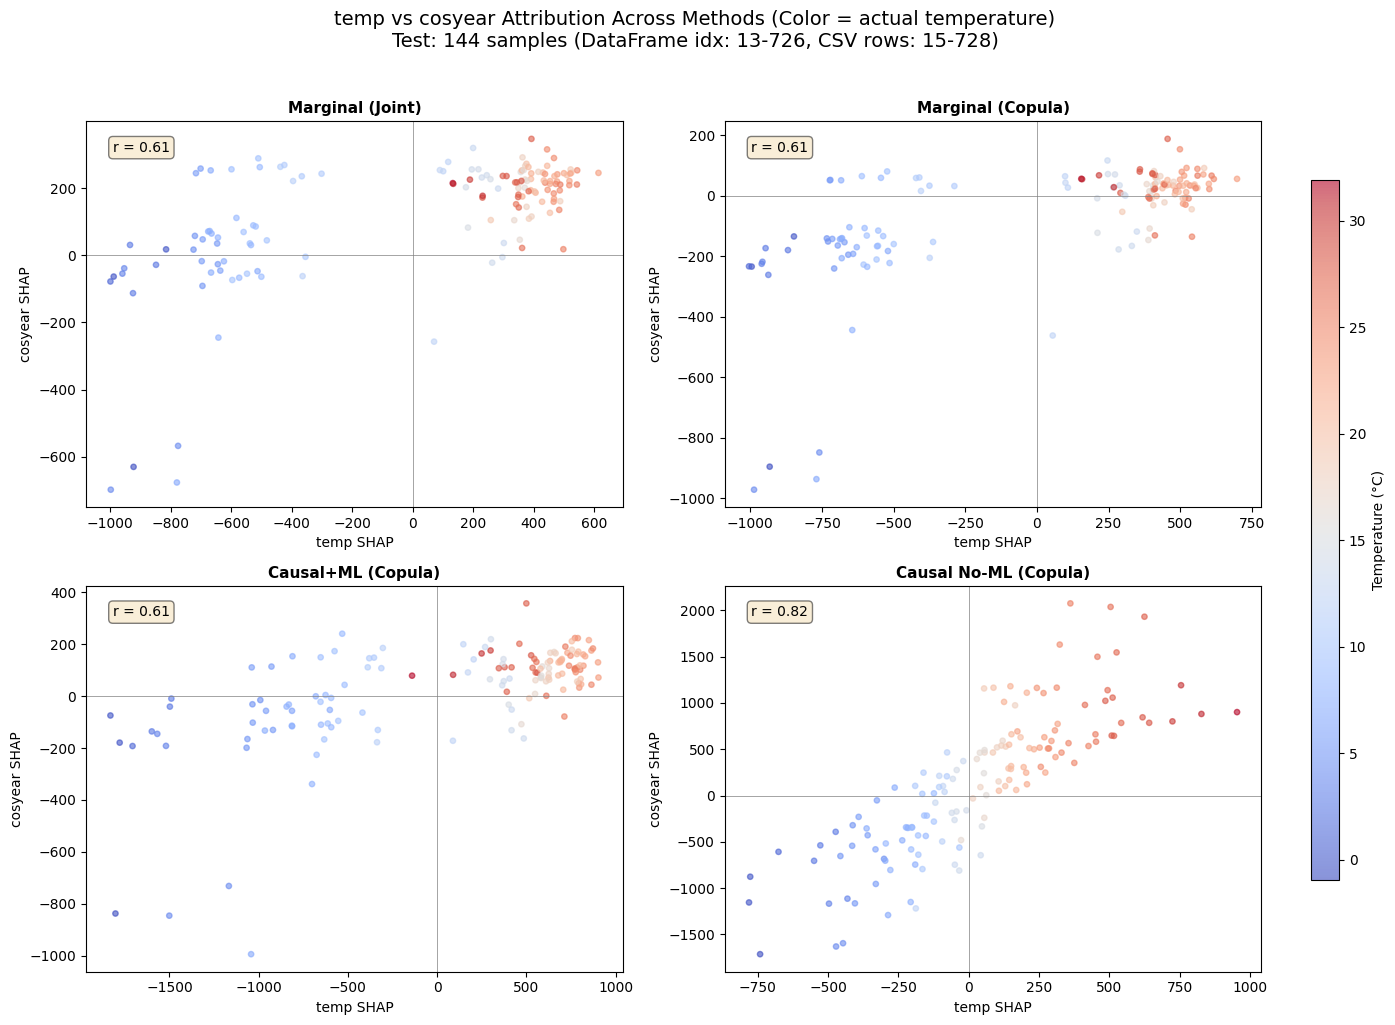

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')
temp_values = X_test[:, temp_idx]

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    scatter = ax.scatter(
        sv[:, temp_idx], 
        sv[:, cosyear_idx], 
        c=temp_values,
        cmap='coolwarm', 
        s=15, 
        alpha=0.6
    )
    
    ax.set_xlabel('temp SHAP')
    ax.set_ylabel('cosyear SHAP')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(exp_name, fontsize=11, fontweight='bold')
    
    corr = np.corrcoef(sv[:, temp_idx], sv[:, cosyear_idx])[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)')

test_csv_rows = test_idx + 2
plt.suptitle(f'temp vs cosyear Attribution Across Methods (Color = actual temperature)\n'
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()


## 12. Grouped Bar Chart: Marginal vs Causal Methods

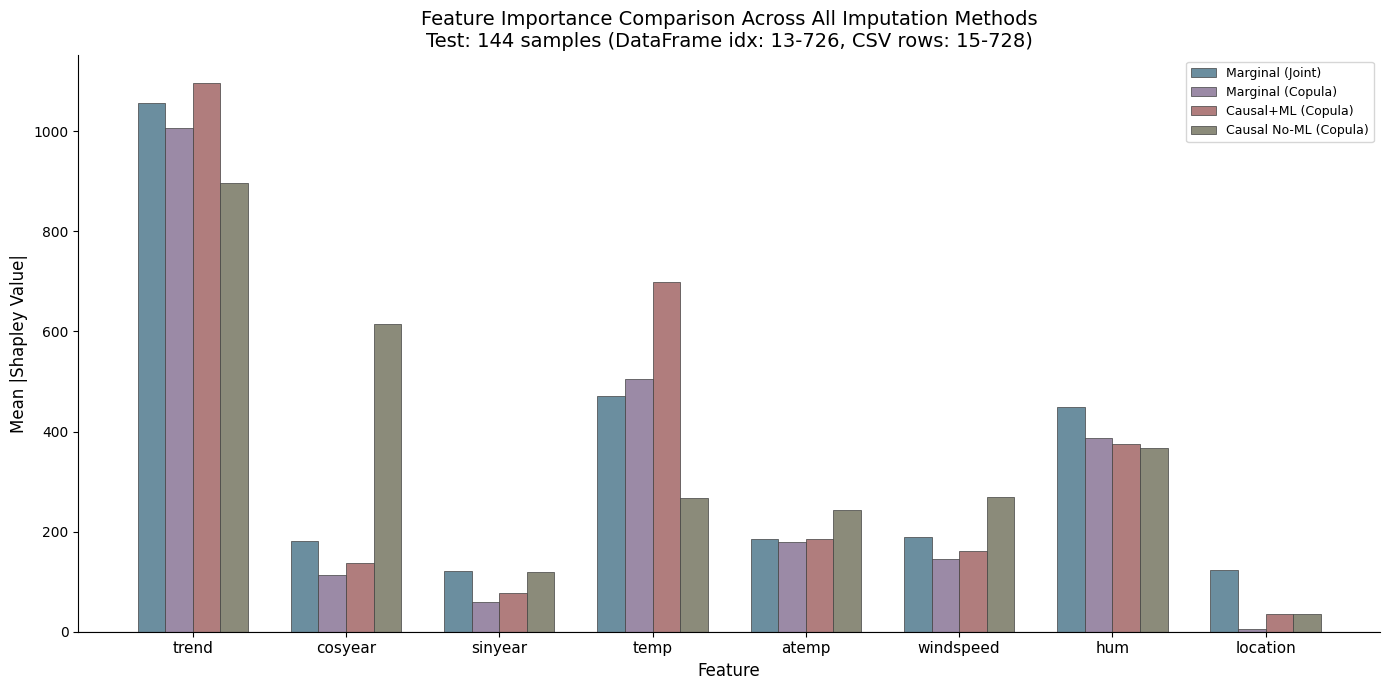

In [16]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(feature_names))
width = 0.18
multiplier = 0

# colors
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-ML)
]

for i, (exp_name, sv) in enumerate(all_sv.items()):
    importance = np.abs(sv).mean(axis=0)
    offset = width * multiplier
    bars = ax.bar(x + offset, importance, width, label=exp_name, color=colors[i], edgecolor='#404040', linewidth=0.5)
    multiplier += 1

ax.set_ylabel('Mean |Shapley Value|', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
test_csv_rows = test_idx + 2
ax.set_title(f'Feature Importance Comparison Across All Imputation Methods\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(feature_names, fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 13. Correlation Matrix Between Methods

How similar are the Shapley values from different methods?

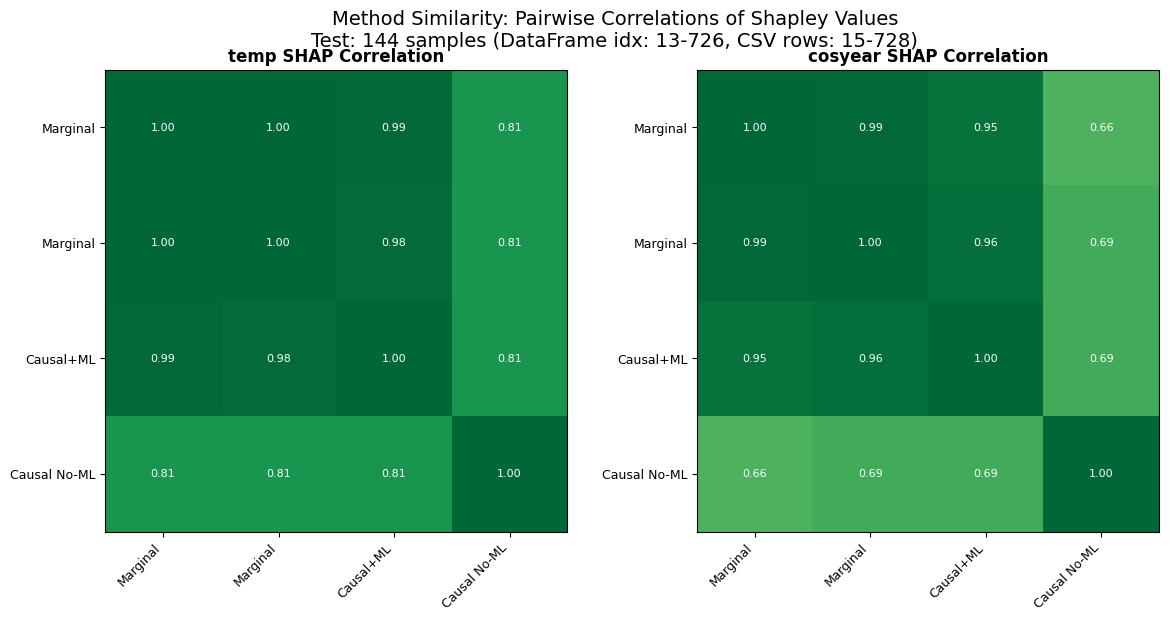

In [17]:
methods = list(all_sv.keys())
n_methods = len(methods)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('cosyear', cosyear_idx)]):
    corr_matrix = np.zeros((n_methods, n_methods))
    
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            corr_matrix[i, j] = np.corrcoef(
                all_sv[m1][:, feat_idx], 
                all_sv[m2][:, feat_idx]
            )[0, 1]
    
    ax = axes[ax_idx]
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    
    ax.set_xticks(range(n_methods))
    ax.set_xticklabels([m.split('(')[0].strip() for m in methods], rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels([m.split('(')[0].strip() for m in methods], fontsize=9)
    
    for i in range(n_methods):
        for j in range(n_methods):
            color = 'white' if abs(corr_matrix[i, j]) > 0.5 else 'black'
            ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', 
                   color=color, fontsize=8)
    
    ax.set_title(f'{feat_name} SHAP Correlation', fontsize=12, fontweight='bold')

test_csv_rows = test_idx + 2
plt.suptitle(f'Method Similarity: Pairwise Correlations of Shapley Values\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, y=0.98)
plt.show()


## 14. Distribution Comparison: Marginal vs Causal Groups

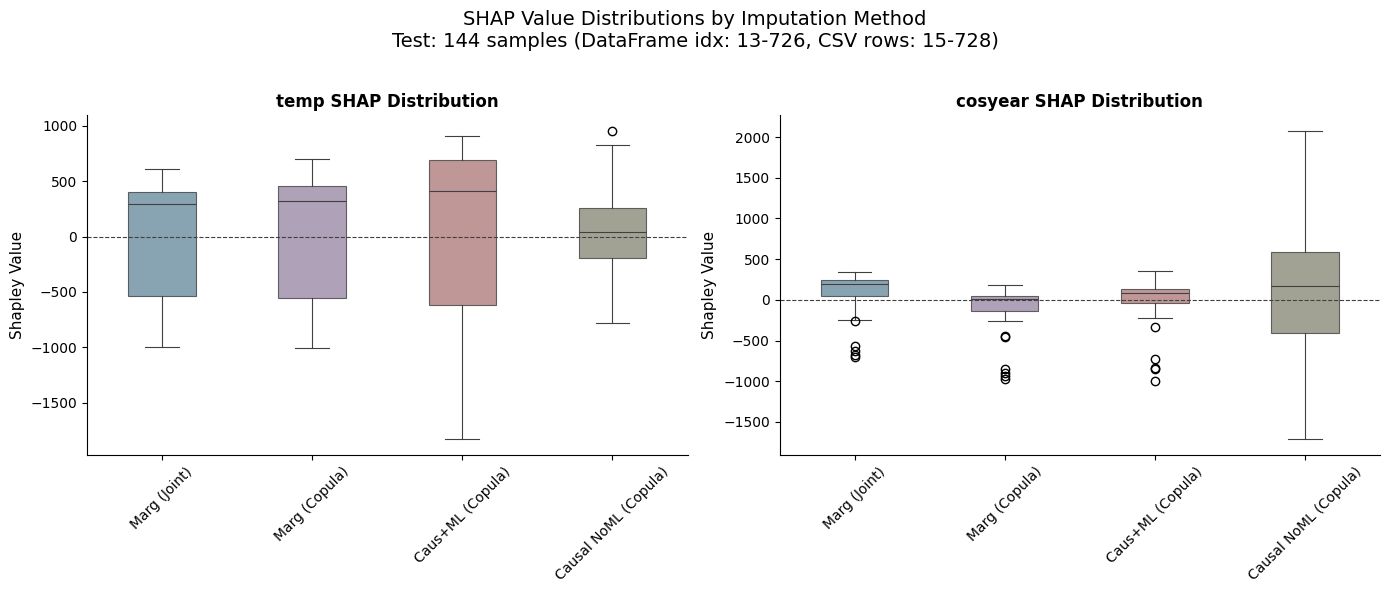

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# colors
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-ML)
]

methods = list(all_sv.keys())

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('cosyear', cosyear_idx)]):
    ax = axes[ax_idx]
    
    data_to_plot = [all_sv[m][:, feat_idx] for m in methods]
    short_names = [m.replace('Marginal', 'Marg').replace('Causal+ML', 'Caus+ML').replace('No-ML', 'NoML') 
                   for m in methods]
    
    bp = ax.boxplot(data_to_plot, labels=short_names, patch_artist=True)
    
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i])
        patch.set_edgecolor('#404040')
        patch.set_linewidth(0.8)
        patch.set_alpha(0.8)
    
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('#404040')
            item.set_linewidth(0.8)
    
    ax.axhline(y=0, color='#404040', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Shapley Value', fontsize=11)
    ax.set_title(f'{feat_name} SHAP Distribution', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

test_csv_rows = test_idx + 2
plt.suptitle(f'SHAP Value Distributions by Imputation Method\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 15. Summary Table and Key Insights

               Method  |temp| mean  |cosyear| mean  cosyear/temp ratio  Category
     Marginal (Joint)   470.243802      182.156454            0.387366  Marginal
    Marginal (Copula)   504.639462      112.639595            0.223208  Marginal
   Causal+ML (Copula)   699.347293      136.648393            0.195394 Causal+ML
Causal No-ML (Copula)   266.764205      615.535202            2.307413     No-ML


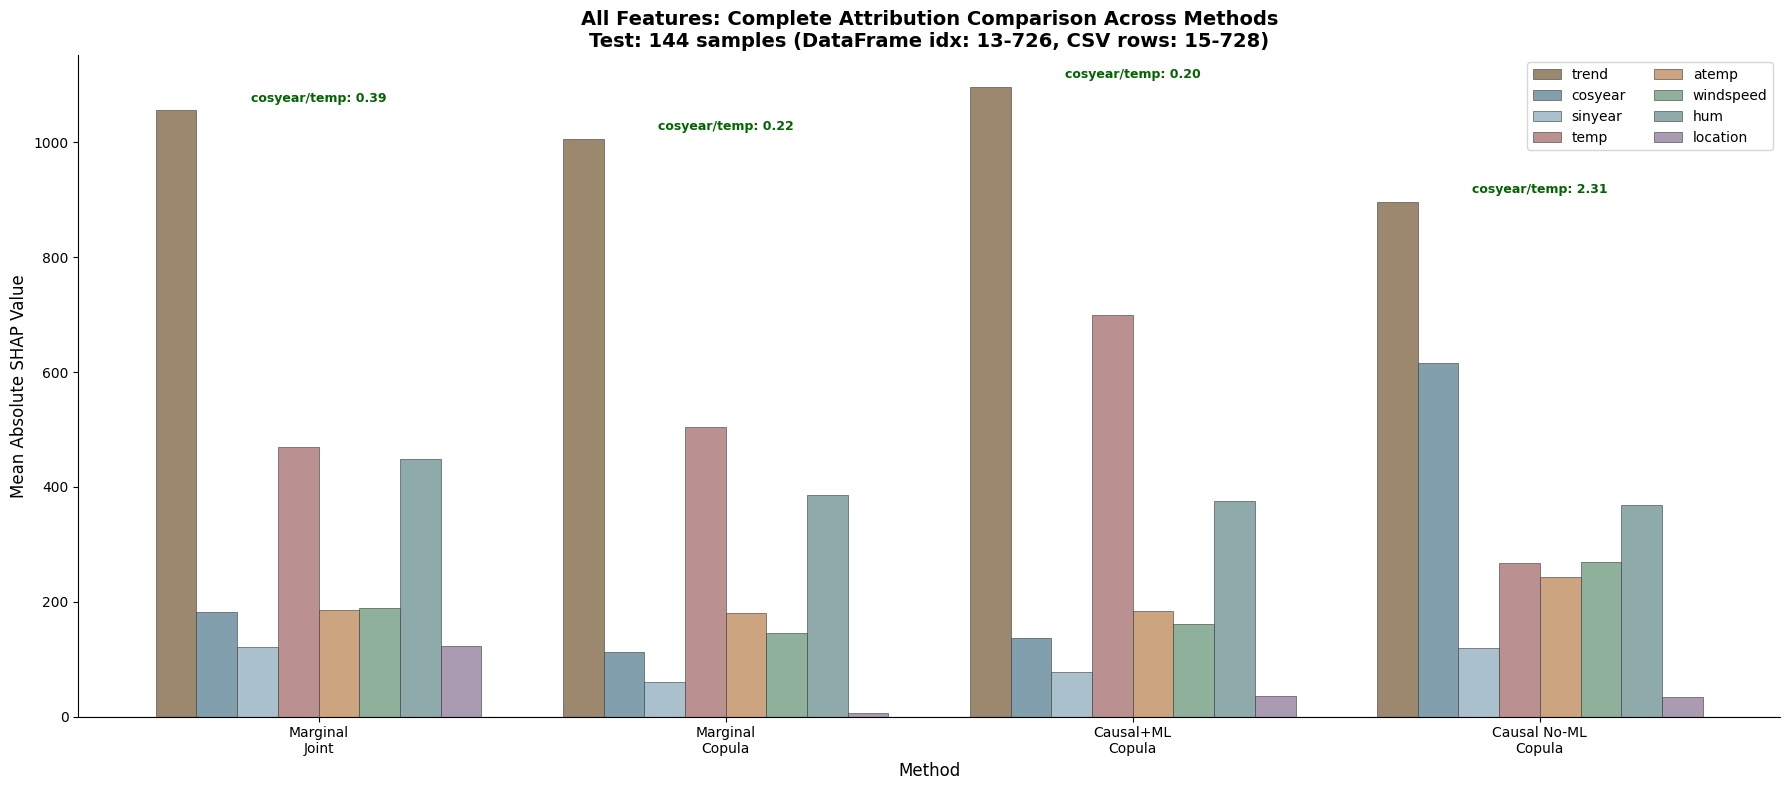

In [19]:
test_csv_rows = test_idx + 2

summary_data = []
for exp_name, sv in all_sv.items():
    temp_mean = np.abs(sv[:, temp_idx]).mean()
    cosyear_mean = np.abs(sv[:, cosyear_idx]).mean()
    ratio = cosyear_mean / temp_mean if temp_mean > 0 else 0
    
    summary_data.append({
        'Method': exp_name,
        '|temp| mean': temp_mean,
        '|cosyear| mean': cosyear_mean,
        'cosyear/temp ratio': ratio,
        'Category': 'Marginal' if 'Marginal' in exp_name else ('No-ML' if 'No-ML' in exp_name else 'Causal+ML')
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(summary_df))
n_features = len(feature_names)
width = 0.8 / n_features
multiplier = 0

# colors
feature_colors = {
    'trend': '#8B7355',      # Muted brown
    'cosyear': '#6B8E9F',    # Muted steel blue
    'sinyear': '#9BB5C4',    # Muted sky blue
    'temp': '#B07D7D',       # Muted rose
    'atemp': '#C4956A',      # Muted terracotta
    'windspeed': '#7BA388',  # Muted sage green
    'hum': '#7A9B9B',        # Muted teal
    'location': '#9B8AA6'    # Muted lavender
}

for feat_name in feature_names:
    feat_idx = feature_names.index(feat_name)
    values = [np.abs(all_sv[exp_name][:, feat_idx]).mean() for exp_name in all_sv.keys()]
    offset = width * multiplier - width * (n_features - 1) / 2
    bars = ax.bar(x + offset, values, width, label=feat_name, 
                 color=feature_colors[feat_name], edgecolor='#404040', linewidth=0.5, alpha=0.85)
    multiplier += 1

ax.set_ylabel('Mean Absolute SHAP Value', fontsize=12)
ax.set_xlabel('Method', fontsize=12)
ax.set_title(f'All Features: Complete Attribution Comparison Across Methods\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.split('(')[0].strip() + '\n' + (m.split('(')[1].replace(')', '') if '(' in m else '') 
                    for m in summary_df['Method']], fontsize=10)
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, row in summary_df.iterrows():
    max_val = max([np.abs(all_sv[row['Method']][:, feature_names.index(f)]).mean() for f in feature_names])
    ax.annotate(f"cosyear/temp: {row['cosyear/temp ratio']:.2f}", 
                xy=(i, max_val + 15),
                ha='center', fontsize=9, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()


## 16. k-SII Network Graph Comparison

> **Note**: This section visualizes **k-Shapley Interaction Index (k-SII)** as network graphs for different imputation methods. 
> 
> **Important**: The k-SII values (max_order=2) were already computed in Section 5, so we directly reuse those results here. The network graphs show:
> - **Nodes**: Features (size proportional to main effect / 1st-order Shapley value)
> - **Edges**: Pairwise interactions (width/color proportional to 2nd-order interaction strength)
>
> This comparison reveals how causal structure affects not just individual attributions, but also **feature interactions**.

In [20]:
sample_idx = len(X_test) // 2  # middle test sample
x_sample = X_test[sample_idx:sample_idx+1]

test_csv_row = test_idx[sample_idx] + 2

print(f"Selected test sample: index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")
print(f"Sample features:")
for i, fname in enumerate(feature_names):
    print(f"  {fname}: {x_sample[0, i]:.2f}")

ksii_results = {}
for exp_name in all_ksii.keys():
    ksii_results[exp_name] = all_ksii[exp_name][sample_idx]
    print(f"  {exp_name}: Retrieved (interactions: {len(ksii_results[exp_name])})")


Selected test sample: index 72 (DataFrame idx: 351, CSV row: 353)
Sample features:
  trend: 351.00
  cosyear: 0.97
  sinyear: -0.24
  temp: 3.20
  atemp: 0.21
  windspeed: 11.38
  hum: 58.63
  location: 1.00
  Marginal (Joint): Retrieved (interactions: 37)
  Marginal (Copula): Retrieved (interactions: 37)
  Causal+ML (Copula): Retrieved (interactions: 37)
  Causal No-ML (Copula): Retrieved (interactions: 37)


k-SII Network Graphs — sample: Test idx 72 (DataFrame idx: 351, CSV row: 353)

Marginal (Joint)


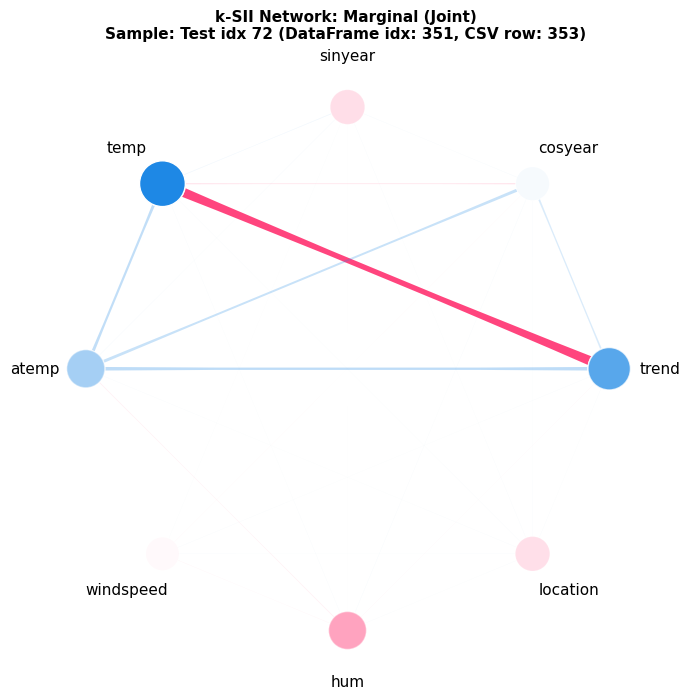


Marginal (Copula)


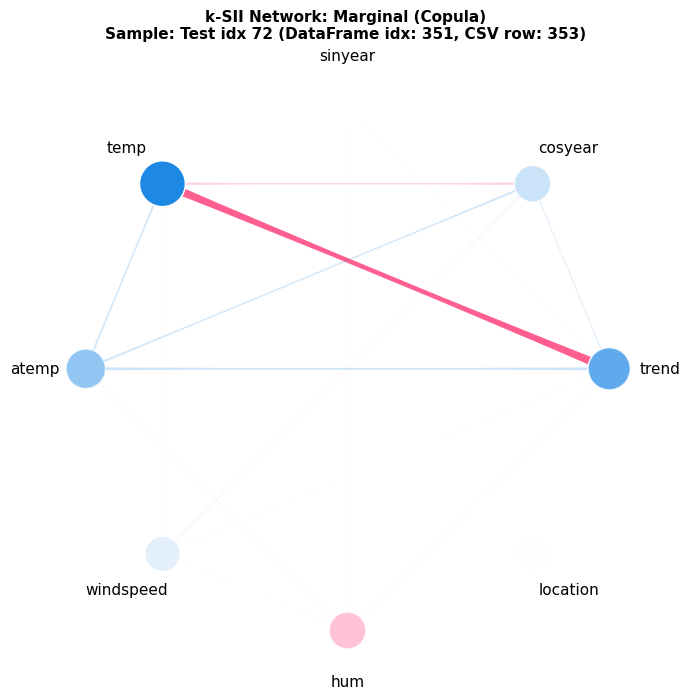


Causal+ML (Copula)


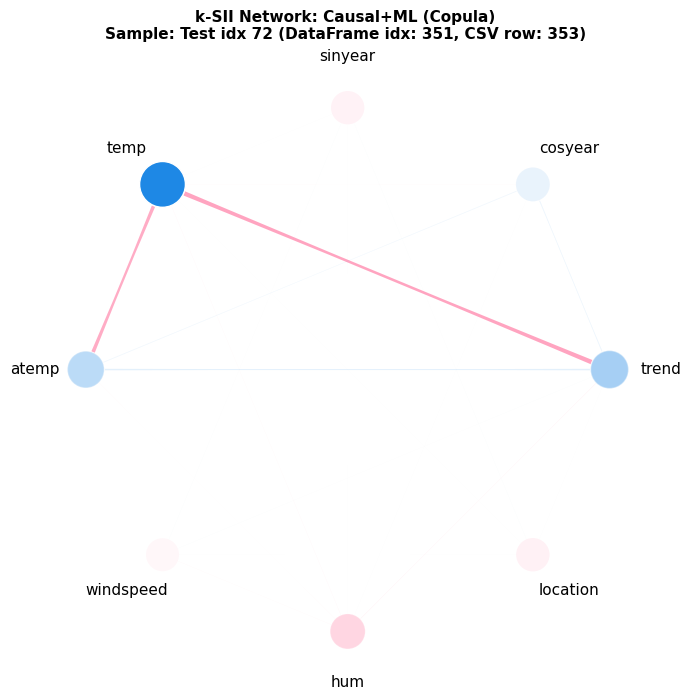


Causal No-ML (Copula)


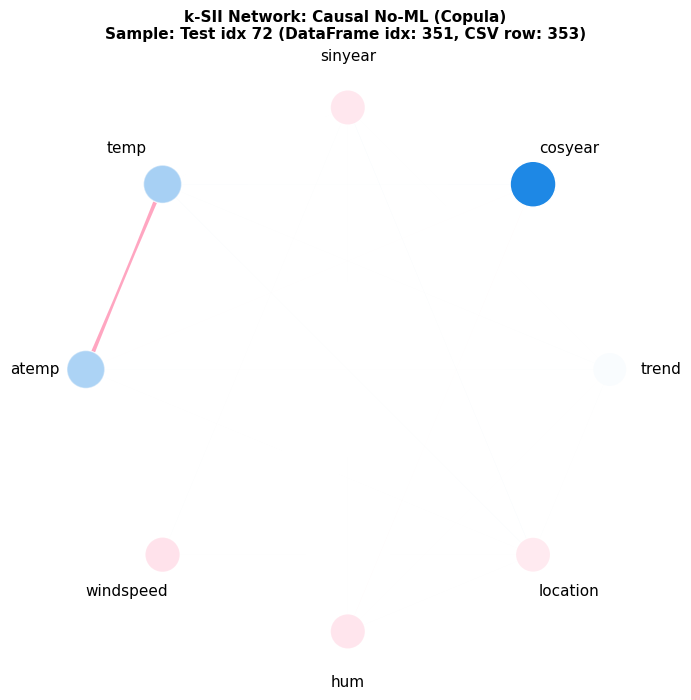

In [21]:
import shapiq

test_csv_row = test_idx[sample_idx] + 2

print(f"k-SII Network Graphs — sample: Test idx {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")

for exp_name, result in ksii_results.items():
    fig, ax = result.plot_network(
        feature_names=feature_names,
        show=False,
    )
    
    print(f"\n{exp_name}")
    
    fig.suptitle(f'k-SII Network: {exp_name}\n'
                f'Sample: Test idx {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})',
                fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [22]:
test_csv_row = test_idx[sample_idx] + 2
print("k-SII INTERACTION VALUES COMPARISON")
print(f"Sample: Test index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")

# Key feature pairs to compare (updated for 8 features including location)
key_pairs = [
    (feature_names.index('temp'), feature_names.index('cosyear')),
    (feature_names.index('temp'), feature_names.index('atemp')),
    (feature_names.index('cosyear'), feature_names.index('sinyear')),
    (feature_names.index('temp'), feature_names.index('hum')),
    (feature_names.index('trend'), feature_names.index('cosyear')),
    (feature_names.index('atemp'), feature_names.index('hum')),
]

print("\n" + "-"*90)
print(f"{'Feature Pair':<25} ", end="")
for exp_name in ksii_results.keys():
    short_name = exp_name.split('(')[0].strip()[:8]
    print(f"{short_name:>12}", end="")
print()
print("-"*90)

for i, j in key_pairs:
    pair_name = f"({feature_names[i]}, {feature_names[j]})"
    print(f"{pair_name:<25} ", end="")
    for exp_name, result in ksii_results.items():
        try:
            interaction_matrix = result.get_n_order_values(2)
            interaction_val = interaction_matrix[i, j] if i < j else interaction_matrix[j, i]
        except Exception:
            interaction_val = 0.0
        print(f"{interaction_val:>12.4f}", end="")
    print()

print("\n" + "-"*90)
print("1st-order (Main Effects):")
print("-"*90)
print(f"{'Feature':<25} ", end="")
for exp_name in ksii_results.keys():
    short_name = exp_name.split('(')[0].strip()[:8]
    print(f"{short_name:>12}", end="")
print()
print("-"*90)

for i, fname in enumerate(feature_names):
    print(f"{fname:<25} ", end="")
    for exp_name, result in ksii_results.items():
        try:
            main_effects = result.get_n_order_values(1)
            main_effect = main_effects[i]
        except Exception:
            main_effect = 0.0
        print(f"{main_effect:>12.4f}", end="")
    print()


k-SII INTERACTION VALUES COMPARISON
Sample: Test index 72 (DataFrame idx: 351, CSV row: 353)

------------------------------------------------------------------------------------------
Feature Pair                  Marginal    Marginal    Causal+M    Causal N
------------------------------------------------------------------------------------------
(temp, cosyear)               101.8709    175.9069     44.7807    -34.2574
(temp, atemp)                -257.7419   -189.1546    533.2187    406.5918
(cosyear, sinyear)            -36.5288      0.5141     -9.0959      1.7222
(temp, hum)                   -29.8235      1.8068     51.4411      6.1407
(trend, cosyear)             -152.4902   -122.4476   -130.3167      2.9922
(atemp, hum)                   58.6964     56.9940     34.3495      8.0425

------------------------------------------------------------------------------------------
1st-order (Main Effects):
---------------------------------------------------------------------------------

In [23]:
from shapiq.interaction_values import aggregate_interaction_values

n_samples_ksii = 10
sample_indices = np.linspace(0, len(X_test)-1, n_samples_ksii, dtype=int)

agg_test_csv_rows = test_idx[sample_indices] + 2
print(f"Aggregating {n_samples_ksii} samples: DataFrame idx {test_idx[sample_indices].tolist()}")

agg_ksii_results = {}

for exp_name in all_ksii.keys():
    results_list = [all_ksii[exp_name][i] for i in sample_indices]
    agg_ksii_results[exp_name] = aggregate_interaction_values(results_list)
    print(f"  {exp_name}: done ({len(results_list)} samples)")

print("\nAggregation complete.")


Aggregating 10 samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
  Marginal (Joint): done (10 samples)
  Marginal (Copula): done (10 samples)
  Causal+ML (Copula): done (10 samples)
  Causal No-ML (Copula): done (10 samples)

Aggregation complete.


Aggregated k-SII Network Graphs (average over 10 test samples):
Samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]

Marginal (Joint)


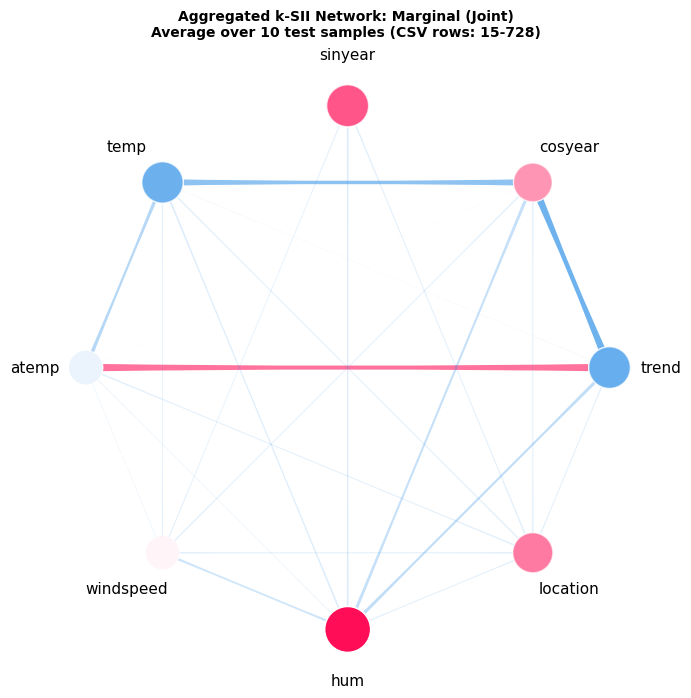


Marginal (Copula)


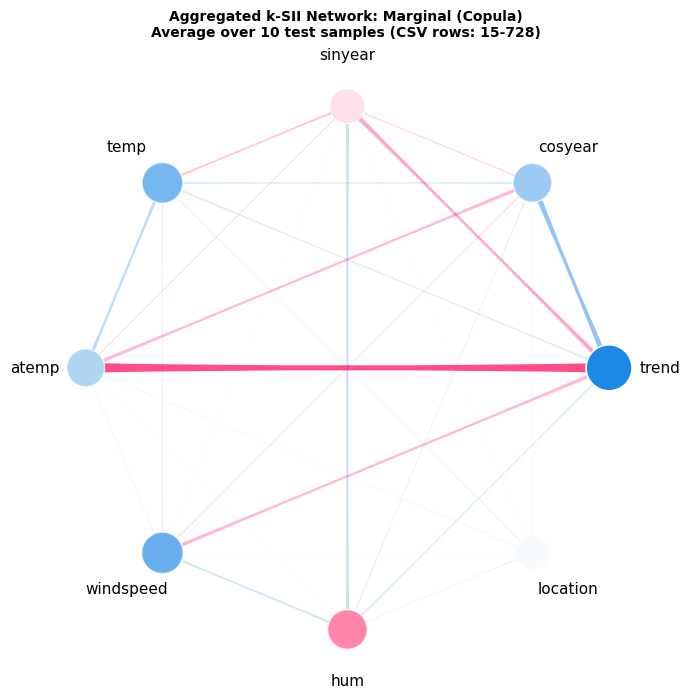


Causal+ML (Copula)


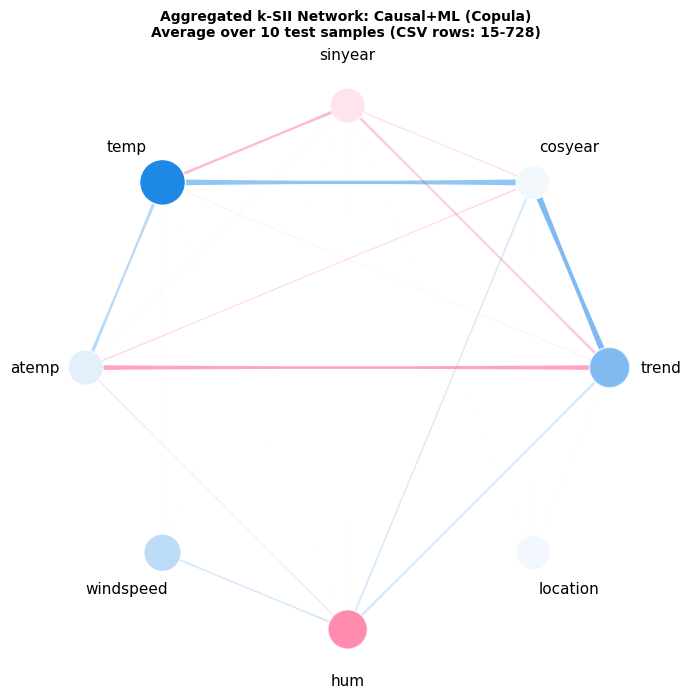


Causal No-ML (Copula)


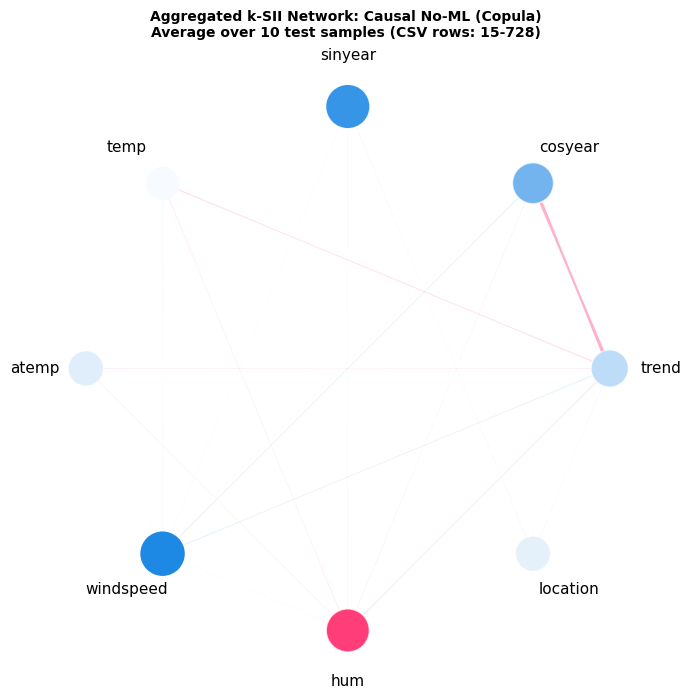

In [24]:
print(f"Aggregated k-SII Network Graphs (average over {n_samples_ksii} test samples):")
print(f"Samples: DataFrame idx {test_idx[sample_indices].tolist()}")

for exp_name, agg_result in agg_ksii_results.items():
    fig, ax = agg_result.plot_network(
        feature_names=feature_names,
        show=False,
    )
    
    print(f"\n{exp_name}")
    
    fig.suptitle(f'Aggregated k-SII Network: {exp_name}\n'
                f'Average over {n_samples_ksii} test samples (CSV rows: {(test_idx[sample_indices] + 2)[0]}-{(test_idx[sample_indices] + 2)[-1]})',
                fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()


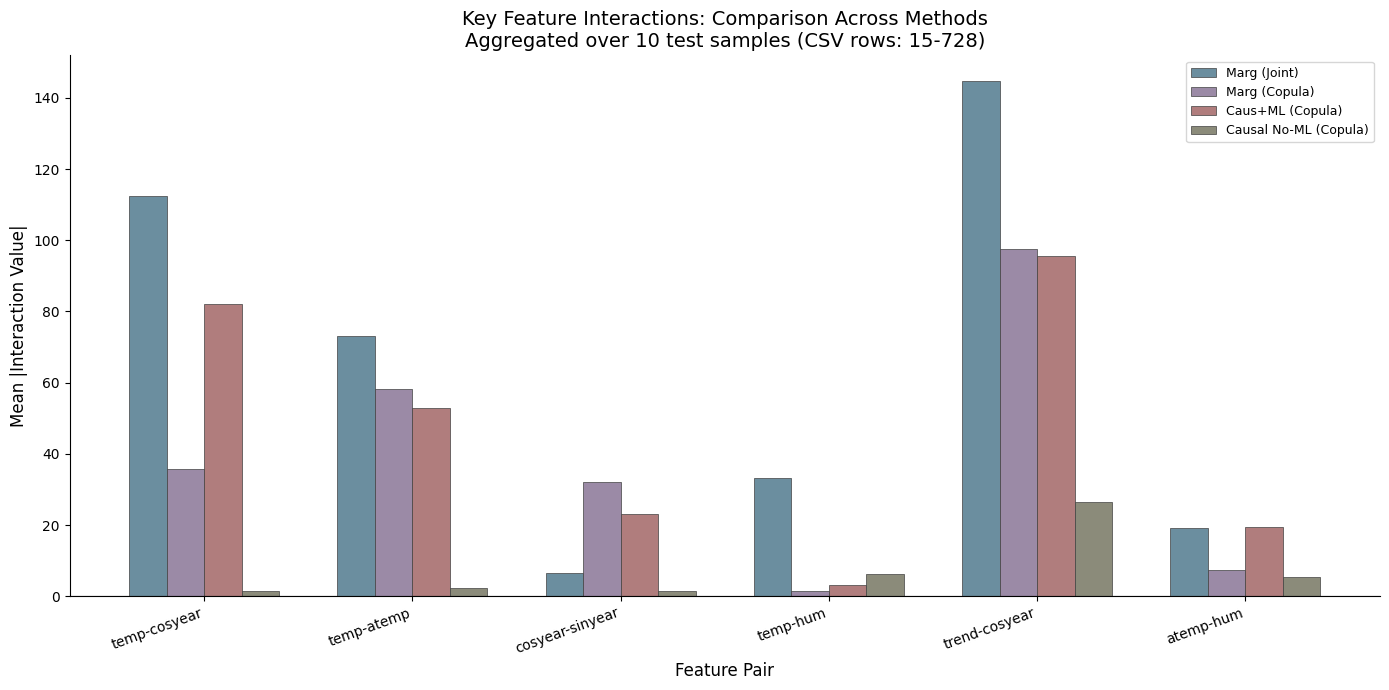

In [25]:
fig, ax = plt.subplots(figsize=(14, 7))

key_pairs_names = [
    ('temp', 'cosyear'),
    ('temp', 'atemp'),
    ('cosyear', 'sinyear'),
    ('temp', 'hum'),
    ('trend', 'cosyear'),
    ('atemp', 'hum'),
]

x = np.arange(len(key_pairs_names))
width = 0.18
multiplier = 0

# colors
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-ML)
]

for color_idx, (exp_name, agg_result) in enumerate(agg_ksii_results.items()):
    values = []
    try:
        int_matrix = agg_result.get_n_order_values(2)
        for f1, f2 in key_pairs_names:
            i, j = feature_names.index(f1), feature_names.index(f2)
            val = abs(int_matrix[i, j]) if i < j else abs(int_matrix[j, i])
            values.append(val)
    except Exception:
        values = [0.0] * len(key_pairs_names)
    
    offset = width * multiplier
    short_name = exp_name.replace('Marginal', 'Marg').replace('Causal+ML', 'Caus+ML')
    bars = ax.bar(x + offset, values, width, label=short_name, 
                 color=colors[color_idx], edgecolor='#404040', linewidth=0.5)
    multiplier += 1

ax.set_ylabel('Mean |Interaction Value|', fontsize=12)
ax.set_xlabel('Feature Pair', fontsize=12)
ax.set_title(f'Key Feature Interactions: Comparison Across Methods\n'
            f'Aggregated over {n_samples_ksii} test samples (CSV rows: {(test_idx[sample_indices] + 2)[0]}-{(test_idx[sample_indices] + 2)[-1]})', 
            fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'{f1}-{f2}' for f1, f2 in key_pairs_names], fontsize=10, rotation=20, ha='right')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Conclusion

This notebook extends the Heskes et al. (2020) analysis with an **alternative causal ordering** that places season and weather variables at the same causal level, and adds `location` as a constant root-cause feature. Below is a summary of key observations from some sections.


### Alternative Causal Structure (Section 3)

The alternative ordering differs from the original paper:
- **Layer 1**: `[trend, location]` — exogenous root causes.
- **Layer 2**: `[cosyear, sinyear, temp, hum, windspeed]` — season and weather variables at the same level (confounded by unobserved `atmospheric_state`).
- **Layer 3**: `[atemp]` — feeling temperature, depends on temp, humidity, and windspeed.

By placing season and weather at the same causal level, the model treats their correlations differently from the original paper's hierarchical structure (trend → season → weather).


### Scatter Plots (Section 6)

- Because season and weather are in the same layer, the attribution shift from `temp` to `cosyear` is different from the original paper's ordering. 

### Comprehensive Imputer Comparison (Section 15)

1. **Causal+ML (Copula) — cosyear/temp ratio decreases**: In this alternative causal ordering, season is **not** modeled as a cause of temperature. Instead, both seasonal variables (`cosyear`, `sinyear`) and weather variables (`temp`, `hum`, `windspeed`) are phenomena jointly produced — directly and indirectly — by the root causes `location` and `trend`. This is the opposite of the original paper's ordering, where placing season *above* temperature in the causal graph caused the cosyear/temp ratio to increase dramatically. Here, without the premise that season causes temperature, the causal model **returns season's attribution back to** the numerically more directly influential `temp`, as well as the root node `trend` whose numerical values also reflect its impact. Although the Causal+ML results appear closer to the Marginal baseline, under this interpretation they **more accurately reflect reality** — season and weather are co-occurring phenomena driven by underlying temporal and spatial factors, not a chain where one causes the other.

2. **cosyear vs sinyear discrepancy**: The two seasonal encoding features (`cosyear` and `sinyear`) exhibit notably different attribution magnitudes, and this gap is especially pronounced in the **No-ML Causal** experiment. Since both features encode the same underlying seasonal cycle (as cosine and sine components), their attributions would be expected to be comparable. The specific mechanism behind this asymmetry warrants further investigation.


### k-SII Interaction Analysis (Section 16)

1. **Main Effects (1st-order)**: Marginal methods assign high main effects to `temp`; causal methods redistribute attribution based on the causal ordering.
2. **Interactions (2nd-order)**: Marginal methods show strong `temp`–`cosyear` interaction (spurious correlation). Causal methods produce different interaction patterns reflecting the dependency structure.
3. **Alternative Ordering Effect**: Placing season and weather at the same causal level (Layer 2) changes how feature correlations are interpreted. The `atemp` feature in Layer 3 shows distinct interaction patterns since it depends on Layer 2 variables.


### Practical Implications


> **Takeaway**: The choice of causal ordering has a significant impact on the resulting Shapley values. Domain knowledge is essential for specifying the correct causal graph.


### References

1. **Causal Shapley Values (reproduced paper)**: Heskes, T., Bucur, I. G., Sijben, E., & Claassen, T. (2020). *Causal Shapley Values: Exploiting Causal Knowledge to Explain Individual Predictions of Complex Models*. Advances in Neural Information Processing Systems (NeurIPS), 33. [arXiv:2011.01625](https://arxiv.org/abs/2011.01625)

2. **k-SII & SHAP-IQ**: Fumagalli, F., Muschalik, M., Kolpaczki, P., Hüllermeier, E., & Hammer, B. (2024). *SHAP-IQ: Unified Estimation of any-order Shapley Interactions*. Advances in Neural Information Processing Systems (NeurIPS), 37.